In [ ]:
# Starter Cell 1 — Mount Drive
from google.colab import drive
drive.mount('/content/drive')
import torch
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Mounted at /content/drive
Device: cuda


In [ ]:
# Starter Cell 2 — Install and imports
!pip install transformers -q
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
print('Done!')

Done!


In [ ]:
# Starter Cell 3 — Paths and constants
RESULTS_DIR  = '/content/drive/MyDrive/stance_detection/results/'
MODELS_DIR   = '/content/drive/MyDrive/stance_detection/models/'
ANALYSIS_DIR = '/content/drive/MyDrive/stance_detection/analysis/'

LABEL2IDX = {'discouraging': 0, 'conditional': 1, 'encouraging': 2}
IDX2LABEL = {0: 'discouraging', 1: 'conditional', 2: 'encouraging'}
LABELS    = ['discouraging', 'conditional', 'encouraging']

print('Paths set!')

Paths set!


In [ ]:
# Starter Cell 4 — Load policy sentences from CRC output
df_policy = pd.read_csv(f'{RESULTS_DIR}07_policy_relevant_sentences.csv')
print(f'Loaded: {len(df_policy):,} policy sentences')
print(df_policy['label'].value_counts())

Loaded: 9,686 policy sentences
label
NEGATIVE    8637
POSITIVE    1049
Name: count, dtype: int64


In [ ]:
# Cell 5 — Stage 2: RoBERTa Stance Classification
#
# Load the best fine-tuned RoBERTa model from notebook 03
# and classify each policy-relevant sentence.
#
# Note: Switch to T4 GPU runtime before running this cell
# Runtime → Change Runtime Type → T4 GPU

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LEN = 128
BATCH_SIZE_INFERENCE = 32  # larger batch for inference (no gradients)

print(f'Device: {DEVICE}')
print(f'Classifying {len(df_policy):,} policy sentences...')


class InferenceDataset(Dataset):
    def __init__(self, sentences, tokenizer, max_len):
        self.sentences = sentences
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.sentences[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze()
        }


# Load best model from notebook 03
model_path = f'{MODELS_DIR}roberta-best_best'
print(f'Loading model from: {model_path}')

tokenizer = AutoTokenizer.from_pretrained(model_path)
model     = AutoModelForSequenceClassification.from_pretrained(model_path)
model     = model.to(DEVICE)
model.eval()
print('Model loaded!')

# Run inference
dataset    = InferenceDataset(df_policy['sentence'].values, tokenizer, MAX_LEN)
loader     = DataLoader(dataset, batch_size=BATCH_SIZE_INFERENCE)

all_preds  = []
all_probs  = []

with torch.no_grad():
    for i, batch in enumerate(loader):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        out  = model(input_ids=ids, attention_mask=mask)
        probs = torch.softmax(out.logits, dim=1)
        preds = torch.argmax(out.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        if i % 50 == 0:
            print(f'  Batch {i+1}/{len(loader)} processed')

# Add predictions to dataframe
df_policy['stance']       = [IDX2LABEL[p] for p in all_preds]
df_policy['stance_conf']  = [max(p) for p in all_probs]
df_policy['prob_disc']    = [p[0] for p in all_probs]
df_policy['prob_cond']    = [p[1] for p in all_probs]
df_policy['prob_enc']     = [p[2] for p in all_probs]

print()
print('Stance classification complete!')
print()
print('Stance distribution (unweighted):')
print(df_policy['stance'].value_counts())
print()
print('Stance distribution (weighted by count):')
for stance in LABELS:
    w = df_policy[df_policy['stance'] == stance]['count'].sum()
    pct = w / df_policy['count'].sum() * 100
    print(f'  {stance:<15}: {w:,} ({pct:.1f}%)')

# Save
stance_path = f'{RESULTS_DIR}07_stance_classified.csv'
df_policy.to_csv(stance_path, index=False)
print(f'\nSaved: {stance_path}')

Device: cuda
Classifying 9,686 policy sentences...
Loading model from: /content/drive/MyDrive/stance_detection/models/roberta-best_best


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded!
  Batch 1/303 processed
  Batch 51/303 processed
  Batch 101/303 processed
  Batch 151/303 processed
  Batch 201/303 processed
  Batch 251/303 processed
  Batch 301/303 processed

Stance classification complete!

Stance distribution (unweighted):
stance
discouraging    7289
conditional     1390
encouraging     1007
Name: count, dtype: int64

Stance distribution (weighted by count):
  discouraging   : 22,068 (72.7%)
  conditional    : 5,611 (18.5%)
  encouraging    : 2,692 (8.9%)

Saved: /content/drive/MyDrive/stance_detection/results/07_stance_classified.csv


=== VALIDATION: RoBERTa Stance vs Existing Sentiment Label ===

Row %: What % of each stance class was labelled NEGATIVE/POSITIVE?
label         NEGATIVE  POSITIVE
stance                          
conditional       83.8      16.2
discouraging      92.6       7.4
encouraging       71.7      28.3
All               89.2      10.8

Weighted cross-tabulation (by count):
  discouraging   : 93.6% NEGATIVE | 6.4% POSITIVE
  conditional    : 90.7% NEGATIVE | 9.3% POSITIVE
  encouraging    : 64.2% NEGATIVE | 35.8% POSITIVE

KEY FINDING:
  If discouraging ≈ NEGATIVE → simple sentiment partly captures stance
  If conditional is mixed → confirms conditional is linguistically ambiguous
  If encouraging ≈ POSITIVE → encouraging sentences have positive tone


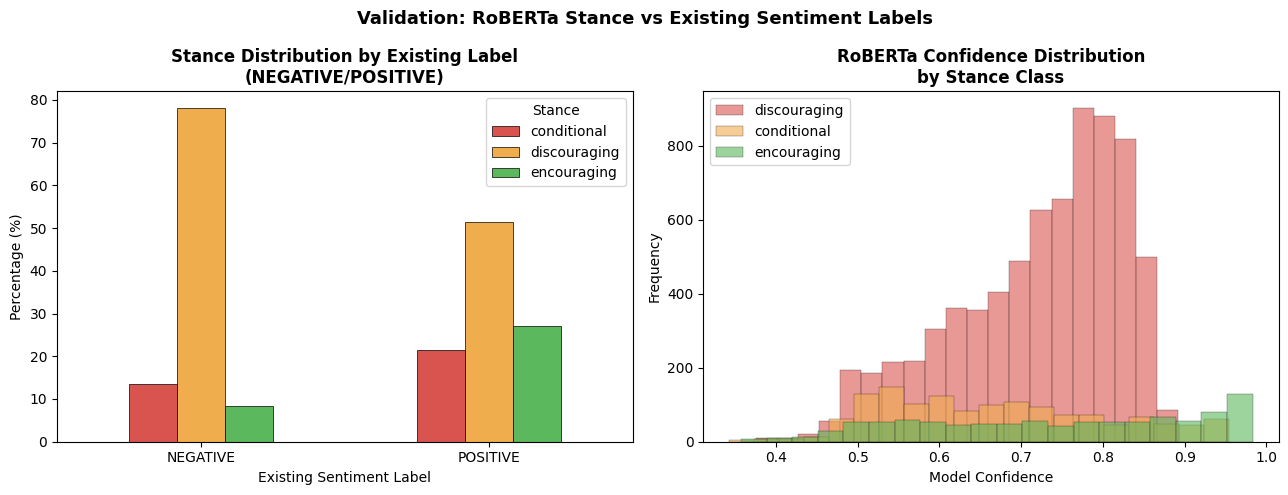

Figure saved!


In [ ]:
# Cell 6 — Validate: Compare RoBERTa stance vs existing sentiment label
#
# This is a validation experiment and a paper finding.
# We compare our stance labels with the existing NEGATIVE/POSITIVE labels.
#
# Hypothesis:
#   NEGATIVE sentiment ≈ discouraging stance
#   POSITIVE sentiment ≈ encouraging stance
#   But conditional sentences may confuse simple sentiment models

print('=== VALIDATION: RoBERTa Stance vs Existing Sentiment Label ===')
print()

# Cross-tabulation
crosstab = pd.crosstab(
    df_policy['stance'],
    df_policy['label'],
    margins=True,
    normalize='index'
).round(3) * 100

print('Row %: What % of each stance class was labelled NEGATIVE/POSITIVE?')
print(crosstab)
print()

# Weighted cross-tabulation
print('Weighted cross-tabulation (by count):')
for stance in LABELS:
    subset = df_policy[df_policy['stance'] == stance]
    neg_w  = subset[subset['label'] == 'NEGATIVE']['count'].sum()
    pos_w  = subset[subset['label'] == 'POSITIVE']['count'].sum()
    total  = neg_w + pos_w
    if total > 0:
        print(f'  {stance:<15}: {neg_w/(total)*100:.1f}% NEGATIVE | {pos_w/(total)*100:.1f}% POSITIVE')

print()
print('KEY FINDING:')
print('  If discouraging ≈ NEGATIVE → simple sentiment partly captures stance')
print('  If conditional is mixed → confirms conditional is linguistically ambiguous')
print('  If encouraging ≈ POSITIVE → encouraging sentences have positive tone')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#d9534f', '#f0ad4e', '#5cb85c']

# Stacked bar: stance breakdown by sentiment label
ct = pd.crosstab(df_policy['label'], df_policy['stance'], normalize='index') * 100
ct.plot(kind='bar', ax=axes[0], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Stance Distribution by Existing Label\n(NEGATIVE/POSITIVE)', fontweight='bold')
axes[0].set_xlabel('Existing Sentiment Label')
axes[0].set_ylabel('Percentage (%)')
axes[0].legend(title='Stance')
axes[0].tick_params(axis='x', rotation=0)

# Confidence distribution by stance
for i, stance in enumerate(LABELS):
    subset = df_policy[df_policy['stance'] == stance]['stance_conf']
    axes[1].hist(subset, bins=20, alpha=0.6, color=colors[i],
                  label=stance, edgecolor='black', linewidth=0.3)
axes[1].set_xlabel('Model Confidence')
axes[1].set_ylabel('Frequency')
axes[1].set_title('RoBERTa Confidence Distribution\nby Stance Class', fontweight='bold')
axes[1].legend()

plt.suptitle('Validation: RoBERTa Stance vs Existing Sentiment Labels',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}07_validation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

=== WEIGHTED STANCE ANALYSIS ===

Total policy sentences (unique)  : 9,686
Total policy sentences (weighted): 30,371

Weighted stance distribution:
(How many course-policy instances fall into each stance?)

  discouraging   :   22,068 instances (72.7%)
  conditional    :    5,611 instances (18.5%)
  encouraging    :    2,692 instances (8.9%)

Unweighted stance distribution (unique sentences):
  discouraging   :  7,289 sentences (75.3%)
  conditional    :  1,390 sentences (14.4%)
  encouraging    :  1,007 sentences (10.4%)

Top 5 most common discouraging sentences:
  [count=358] Do not use Wikipedia as a source for your information...
  [count=341] This means that most websites (Wikipedia, answers.com, and similar websites) are disqualified...
  [count=331] Do not use Wikipedia...
  [count=254] See "Using Wikipedia -- "Danger Will Robinson" handout located on the "Syllabus" page or this recent...
  [count=253] --Review and be familiar with ALL Course Policies located including the SafeA

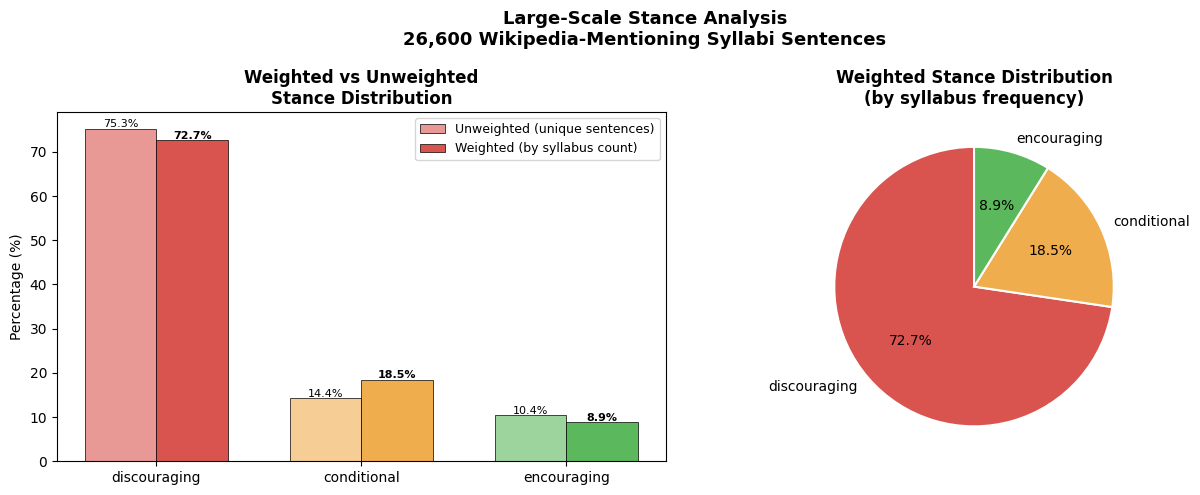

Figure saved!


In [ ]:
# Cell 7 — Weighted stance analysis
#
# The count column tells us how many syllabi contain each sentence.
# Weighting by count gives us the TRUE distribution across the corpus —
# not just unique sentences, but actual policy exposure.
#
# Example: if "Wikipedia should not be cited" appears in 664 syllabi,
# it contributes 664 times to the weighted count,correctly reflecting
# that 664 courses have this policy.

print('=== WEIGHTED STANCE ANALYSIS ===')
print()

total_weighted = df_policy['count'].sum()

print(f'Total policy sentences (unique)  : {len(df_policy):,}')
print(f'Total policy sentences (weighted): {total_weighted:,}')
print()

print('Weighted stance distribution:')
print('(How many course-policy instances fall into each stance?)')
print()

weighted_counts = {}
for stance in LABELS:
    subset = df_policy[df_policy['stance'] == stance]
    w      = subset['count'].sum()
    pct    = w / total_weighted * 100
    weighted_counts[stance] = w
    print(f'  {stance:<15}: {w:>8,} instances ({pct:.1f}%)')

print()
print('Unweighted stance distribution (unique sentences):')
for stance in LABELS:
    n   = (df_policy['stance'] == stance).sum()
    pct = n / len(df_policy) * 100
    print(f'  {stance:<15}: {n:>6,} sentences ({pct:.1f}%)')

# Plot weighted vs unweighted comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#d9534f', '#f0ad4e', '#5cb85c']
x = np.arange(len(LABELS))
w = 0.35

unweighted = [( df_policy['stance'] == s).sum() for s in LABELS]
weighted   = [weighted_counts[s] for s in LABELS]

# Normalise for comparison
unw_pct = [u/sum(unweighted)*100 for u in unweighted]
w_pct   = [w/sum(weighted)*100   for w in weighted]

b1 = axes[0].bar(x-w/2, unw_pct, w, label='Unweighted (unique sentences)',
                  color=[c+'99' for c in ['#d9534f','#f0ad4e','#5cb85c']],
                  edgecolor='black', linewidth=0.5)
b2 = axes[0].bar(x+w/2, w_pct,   w, label='Weighted (by syllabus count)',
                  color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(LABELS)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Weighted vs Unweighted\nStance Distribution', fontweight='bold')
axes[0].legend(fontsize=9)
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8)
for bar in b2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=8, fontweight='bold')

# Top 10 most common sentences per stance
for i, stance in enumerate(LABELS):
    subset   = df_policy[df_policy['stance'] == stance]
    top10    = subset.nlargest(10, 'count')[['sentence','count']]
    print(f'\nTop 5 most common {stance} sentences:')
    for _, row in top10.head(5).iterrows():
        print(f'  [count={row["count"]}] {str(row["sentence"])[:100]}...')

# Pie chart weighted
axes[1].pie(
    [weighted_counts[s] for s in LABELS],
    labels=LABELS,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
axes[1].set_title('Weighted Stance Distribution\n(by syllabus frequency)', fontweight='bold')

plt.suptitle('Large-Scale Stance Analysis\n26,600 Wikipedia-Mentioning Syllabi Sentences',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}07_weighted_stance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')

In [ ]:
# Cell 8 — Top sentences analysis
#
# The most frequently occurring policy sentences are the most impactful
# they represent institutional consensus across many syllabi.
# This is a novel finding enabled by the count column.

print('=== MOST INFLUENTIAL POLICY SENTENCES ===')
print('(Ranked by frequency across syllabi)')
print()

for stance in LABELS:
    subset = df_policy[df_policy['stance'] == stance].nlargest(5, 'count')
    print(f'TOP 5 {stance.upper()} SENTENCES:')
    print('-' * 60)
    for rank, (_, row) in enumerate(subset.iterrows(), 1):
        print(f'{rank}. [Appears in {row["count"]:,} syllabi]')
        print(f'   {str(row["sentence"])[:150]}')
        print(f'   Confidence: {row["stance_conf"]:.3f}')
        print()
    print()

# High confidence vs low confidence analysis
print('=== CONFIDENCE ANALYSIS ===')
high_conf = df_policy[df_policy['stance_conf'] >= 0.90]
low_conf  = df_policy[df_policy['stance_conf'] <  0.70]

print(f'High confidence (≥0.90): {len(high_conf):,} sentences ({len(high_conf)/len(df_policy)*100:.1f}%)')
print(f'Low confidence  (<0.70): {len(low_conf):,}  sentences ({len(low_conf)/len(df_policy)*100:.1f}%)')
print()
print('Low confidence sentences are likely borderline cases — worth manual review')
print()
print('Low confidence stance distribution:')
print(low_conf['stance'].value_counts())
print()
print('NOTE: High low-confidence in conditional class confirms it is')
print('the most linguistically ambiguous category — consistent with')
print('our classifier evaluation results.')

=== MOST INFLUENTIAL POLICY SENTENCES ===
(Ranked by frequency across syllabi)

TOP 5 DISCOURAGING SENTENCES:
------------------------------------------------------------
1. [Appears in 358 syllabi]
   Do not use Wikipedia as a source for your information
   Confidence: 0.604

2. [Appears in 341 syllabi]
   This means that most websites (Wikipedia, answers.com, and similar websites) are disqualified
   Confidence: 0.701

3. [Appears in 331 syllabi]
   Do not use Wikipedia
   Confidence: 0.849

4. [Appears in 254 syllabi]
   See "Using Wikipedia -- "Danger Will Robinson" handout located on the "Syllabus" page or this recent CNN article, "Use with caution: The perils of Wik
   Confidence: 0.751

5. [Appears in 253 syllabi]
   --Review and be familiar with ALL Course Policies located including the SafeAssign, Wikipedia and [PERSON] [PERSON]
   Confidence: 0.637


TOP 5 CONDITIONAL SENTENCES:
------------------------------------------------------------
1. [Appears in 554 syllabi]
   Be awa

=== COMPARISON: Manual (354) vs Large-Scale  ===

Manual annotation distribution (354 sentences):
  discouraging   : 82.5%
  conditional    : 9.6%
  encouraging    : 7.9%

Large-scale distribution (unweighted):
  discouraging   : 75.3%
  conditional    : 14.4%
  encouraging    : 10.4%

Large-scale distribution (weighted by count):
  discouraging   : 72.7%
  conditional    : 18.5%
  encouraging    : 8.9%


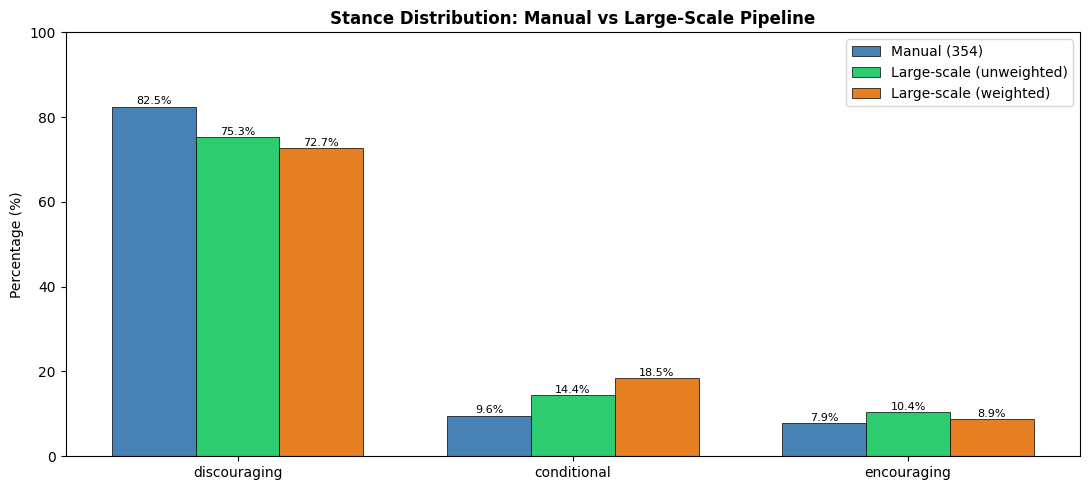

Figure saved!

KEY FINDING: If distributions are similar across all three bars,
the large-scale pipeline produces results consistent with
manual annotation — validating the automated approach.


In [ ]:
# Cell 9 — Comparison with manually annotated dataset
#
# Compare the large-scale results with our 354 manually annotated sentences.
# This validates that the automated pipeline produces results consistent
# with human annotation.

print('=== COMPARISON: Manual (354) vs Large-Scale  ===')
print()

manual_dist = {
    'discouraging': 292/354*100,
    'conditional' :  34/354*100,
    'encouraging' :  28/354*100
}

print('Manual annotation distribution (354 sentences):')
for stance, pct in manual_dist.items():
    print(f'  {stance:<15}: {pct:.1f}%')

print()
print('Large-scale distribution (unweighted):')
large_unweighted = {}
for stance in LABELS:
    n   = (df_policy['stance'] == stance).sum()
    pct = n / len(df_policy) * 100
    large_unweighted[stance] = pct
    print(f'  {stance:<15}: {pct:.1f}%')

print()
print('Large-scale distribution (weighted by count):')
large_weighted = {}
for stance in LABELS:
    w   = df_policy[df_policy['stance'] == stance]['count'].sum()
    pct = w / df_policy['count'].sum() * 100
    large_weighted[stance] = pct
    print(f'  {stance:<15}: {pct:.1f}%')

# Plot three-way comparison
fig, ax = plt.subplots(figsize=(11, 5))
x  = np.arange(len(LABELS))
w  = 0.25
colors = ['#4682b4', '#2ecc71', '#e67e22']

b1 = ax.bar(x-w,   [manual_dist[s]      for s in LABELS], w,
             label='Manual (354)', color=colors[0], edgecolor='black', linewidth=0.5)
b2 = ax.bar(x,     [large_unweighted[s] for s in LABELS], w,
             label='Large-scale (unweighted)', color=colors[1], edgecolor='black', linewidth=0.5)
b3 = ax.bar(x+w,   [large_weighted[s]   for s in LABELS], w,
             label='Large-scale (weighted)', color=colors[2], edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(LABELS)
ax.set_ylabel('Percentage (%)')
ax.set_title('Stance Distribution: Manual vs Large-Scale Pipeline',
             fontweight='bold', fontsize=12)
ax.legend()
ax.set_ylim(0, 100)

for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(f'{ANALYSIS_DIR}07_manual_vs_largescale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved!')
print()
print('KEY FINDING: If distributions are similar across all three bars,')
print('the large-scale pipeline produces results consistent with')
print('manual annotation — validating the automated approach.')

In [ ]:
# Cell 10 — Save all results and print summary
# Save final classified dataset
final_path = f'{RESULTS_DIR}07_final_classified.csv'
df_policy.to_csv(final_path, index=False)
print(f'Final dataset saved: {final_path}')
print(f'Rows: {len(df_policy):,}')
print(f'Columns: {df_policy.columns.tolist()}')
print()

# Check confidence column name
conf_col = None
for candidate in ['stance_conf', 'confidence', 'max_prob', 'score']:
    if candidate in df_policy.columns:
        conf_col = candidate
        break
if conf_col:
    print(f'Confidence column found: "{conf_col}"')
else:
    print('WARNING: No confidence column found — skipping confidence summary')
print()

print('=' * 60)
print('  NOTEBOOK 07 COMPLETE — SUMMARY')
print('=' * 60)
print()
print(f'Input sentences        : 26,600')
print(f'Policy-relevant (Qwen) : {len(df_policy):,}')
print(f'Policy rate            : {len(df_policy)/26600*100:.1f}%')
print()

# Confidence breakdown
if conf_col:
    low_conf  = (df_policy[conf_col] < 0.70).sum()
    pct_low   = low_conf / len(df_policy) * 100
    print(f'Low confidence (<0.70) : {low_conf:,} ({pct_low:.1f}%)')
    print(f'High confidence (>=0.70): {len(df_policy)-low_conf:,} ({100-pct_low:.1f}%)')
    print()

print('Stance classification (weighted):')
for stance in LABELS:
    w   = df_policy[df_policy['stance'] == stance]['count'].sum()
    pct = w / df_policy['count'].sum() * 100
    print(f'  {stance:<15}: {w:,} instances ({pct:.1f}%)')
print()

print('Files saved:')
files = [
    '07_policy_relevant_sentences.csv',
    '07_stance_classified.csv',
    '07_final_classified.csv',
]
for f in files:
    p = f'{RESULTS_DIR}{f}'
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  [{status}] {f}')
print()

print('Analysis figures saved:')
figs = [
    '07_validation_comparison.png',
    '07_weighted_stance_distribution.png',
    '07_manual_vs_largescale.png',
]
for f in figs:
    p = f'{ANALYSIS_DIR}{f}'
    status = 'OK' if os.path.exists(p) else 'MISSING'
    print(f'  [{status}] {f}')
print()
print('Next: 04_inter_annotator_agreement.ipynb + GenAI Excel analysis')
print('=' * 60)

Final dataset saved: /content/drive/MyDrive/stance_detection/results/07_final_classified.csv
Rows: 9,686
Columns: ['sentence', 'count', 'sentiment', 'label', 'score', 'policy_relevant', 'policy_relevance_score', 'stance', 'stance_conf', 'prob_disc', 'prob_cond', 'prob_enc']

Confidence column found: "stance_conf"

  NOTEBOOK 07 COMPLETE — SUMMARY

Input sentences        : 26,600
Policy-relevant (Qwen) : 9,686
Policy rate            : 36.4%

Low confidence (<0.70) : 3,889 (40.2%)
High confidence (>=0.70): 5,797 (59.8%)

Stance classification (weighted):
  discouraging   : 22,068 instances (72.7%)
  conditional    : 5,611 instances (18.5%)
  encouraging    : 2,692 instances (8.9%)

Files saved:
  [OK] 07_policy_relevant_sentences.csv
  [OK] 07_stance_classified.csv
  [OK] 07_final_classified.csv

Analysis figures saved:
  [OK] 07_validation_comparison.png
  [OK] 07_weighted_stance_distribution.png
  [OK] 07_manual_vs_largescale.png

Next: 04_inter_annotator_agreement.ipynb + GenAI Excel 